In [8]:
#!/usr/bin/env python
# coding: utf-8

# Copyright (c) 2026 Walker Rowe. SPDX-License-Identifier: MIT.
# Data source: DeepStateMap.Live
# https://deepstatemap.live/en#6/49.4383200/32.0526800
# Concepts, project design, and most code: Walker Rowe.
# AI tools were used to review, debug, document, and enhance this work.
# DeepState supplies the underlying battlefield geometries, labels,
# classifications, and snapshot times; this analysis does not independently
# verify those source observations.

# # Ukraine Battlefield Analysis - Combined View
# This notebook combines:
# - Area-specific calculations for Vovchansk (or other regions)
# - Full Ukraine interactive map with color-coded territories

# ## Cell 1: Imports and Setup

import pymongo
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape, Polygon, Point, box
from shapely import wkt
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()

user = os.getenv("MONGODB_USER")
pwd = os.getenv("MONGODB_PWD")
cluster = os.getenv("CLUSTER")

if not user or not pwd:
    raise ValueError("Missing credentials! Please check your .env file.")

connection_string = f"mongodb+srv://{user}:{pwd}@{cluster}"
client = pymongo.MongoClient(connection_string)




In [9]:
# ## Cell 2: Load Historical Data from MongoDB

geom_field = 'geometry'
db = client['geodb']
collection = db['geodata']
data = list(collection.find({}))
df = pd.DataFrame(data)

if geom_field in df.columns:
    df[geom_field] = df[geom_field].apply(lambda x: shape(x) if x else None)

gdf_historical = gpd.GeoDataFrame(df, geometry=geom_field)
print(f"Loaded {len(gdf_historical)} records from MongoDB")


# ## Cell 3: Define Areas of Interest



# Automatically select the compact area with the largest Ukrainian gain
# during the most recent seven-day comparison. The input polygons may be
# very large: the selector measures only their exact changed geometry.
from shapely.ops import unary_union
from shapely.prepared import prep
import numpy as np

LOOKBACK_DAYS = 7
HOTSPOT_WINDOW_KM = 15  # Size of the compact area returned
HOTSPOT_STRIDE_KM = 5   # Smaller values give a finer, slower search
MIN_GAIN_KM2 = 0.01     # Keep sub-square-kilometre changes detectable
AREA_CRS = "EPSG:3035"  # Equal-area projection suitable for Europe

def _deepstate_status(properties):
    """Normalize a DeepState feature name to an analysis status."""
    if not isinstance(properties, dict):
        return None
    name = str(properties.get("name", "")).lower()
    # Prefer DeepState's machine-readable suffix. Looking only at the last
    # /// field loses the English label because that field is the layer key.
    if "geojson.status.dismissed" in name or "liberated" in name:
        return "liberated"
    if "geojson.status.unknown" in name or "unknown status" in name:
        return "gray"
    if (
        "geojson.status.occupied" in name
        or "geojson.territories.ordlo" in name
        or "geojson.territories.crimea" in name
    ):
        return "occupied"
    return None

def _union_status(frame, status):
    geometries = [
        geom.buffer(0)
        for geom in frame.loc[frame["status"] == status, "geometry"]
        if geom is not None and not geom.is_empty
    ]
    return unary_union(geometries) if geometries else None

def select_weekly_ukrainian_hotspot(gdf):
    work = gdf.dropna(subset=["geometry", "epoch_time"]).copy()
    work["dt"] = pd.to_datetime(work["epoch_time"], unit="s").dt.normalize()
    work["status"] = work["properties"].apply(_deepstate_status)
    work = work[work["status"].notna()]
    work = gpd.GeoDataFrame(work, geometry="geometry", crs="EPSG:4326")

    dates = pd.DatetimeIndex(sorted(work["dt"].unique()))
    latest_date = dates[-1]
    eligible = dates[dates <= latest_date - pd.Timedelta(days=LOOKBACK_DAYS)]
    if eligible.empty:
        raise ValueError("Not enough history for the requested lookback period")
    baseline_date = eligible[-1]

    projected = work.to_crs(AREA_CRS)
    before = projected[projected["dt"] == baseline_date]
    latest = projected[projected["dt"] == latest_date]

    occupied_before = _union_status(before, "occupied")
    liberated_before = _union_status(before, "liberated")
    liberated_latest = _union_status(latest, "liberated")
    occupied_latest = _union_status(latest, "occupied")
    if occupied_before is None or liberated_latest is None:
        raise ValueError("The comparison snapshots lack occupied or liberated geometry")

    # Prefer a confirmed occupied -> liberated transition. If the source
    # layers do not overlap cleanly, fall back to newly liberated geometry.
    gain = occupied_before.intersection(liberated_latest)
    gain_method = "occupied to liberated"
    if gain.is_empty or gain.area / 1_000_000 < MIN_GAIN_KM2:
        if liberated_before is None:
            raise ValueError("No earlier liberated geometry is available")
        gain = liberated_latest.difference(liberated_before)
        gain_method = "newly liberated"
    if gain.is_empty or gain.area / 1_000_000 < MIN_GAIN_KM2:
        raise ValueError("No Ukrainian gain above MIN_GAIN_KM2 was found")

    # Search overlapping compact windows. Scoring uses the exact vector
    # intersection area, not the size of the source polygon or grid cell.
    window_m = HOTSPOT_WINDOW_KM * 1_000
    stride_m = HOTSPOT_STRIDE_KM * 1_000
    half_window = window_m / 2
    minx, miny, maxx, maxy = gain.bounds
    xs = np.arange(minx, maxx + stride_m, stride_m)
    ys = np.arange(miny, maxy + stride_m, stride_m)
    prepared_gain = prep(gain)
    best_window = None
    best_gain_m2 = -1

    for x in xs:
        for y in ys:
            candidate = box(
                x - half_window, y - half_window,
                x + half_window, y + half_window,
            )
            if not prepared_gain.intersects(candidate):
                continue
            changed_m2 = gain.intersection(candidate).area
            if changed_m2 > best_gain_m2:
                best_window = candidate
                best_gain_m2 = changed_m2

    # Measure the opposite-direction change in the same winning window.
    # This is called newly mapped occupied, rather than confirmed land lost,
    # because the source lacks a wall-to-wall Ukrainian-control layer.
    newly_occupied_m2 = 0.0
    if occupied_latest is not None:
        newly_occupied = occupied_latest.difference(occupied_before)
        if not newly_occupied.is_empty:
            newly_occupied_m2 = newly_occupied.intersection(best_window).area

    # Pressure indicator: area that was occupied at baseline and is now gray.
    # When DeepState reclassifies formerly occupied land as contested/unknown
    # it is the earliest signal that Ukraine may be contesting that ground.
    gray_latest = _union_status(latest, "gray")
    occupied_to_gray_m2 = 0.0
    if gray_latest is not None:
        occ_to_gray = occupied_before.intersection(gray_latest)
        if not occ_to_gray.is_empty:
            occupied_to_gray_m2 = occ_to_gray.intersection(best_window).area

    best_window_ll = gpd.GeoSeries([best_window], crs=AREA_CRS).to_crs(4326).iloc[0]
    min_lon, min_lat, max_lon, max_lat = best_window_ll.bounds
    selected_area = {
        "top_left": (max_lat, min_lon),
        "bottom_right": (min_lat, max_lon),
    }
    details = {
        "latest_date": latest_date,
        "baseline_date": baseline_date,
        "gain_km2_in_window": best_gain_m2 / 1_000_000,
        "method": gain_method,
        "newly_occupied_km2_in_window": newly_occupied_m2 / 1_000_000,
        "occupied_to_gray_km2_in_window": occupied_to_gray_m2 / 1_000_000,
    }
    return selected_area, details

area, hotspot = select_weekly_ukrainian_hotspot(gdf_historical)
area_name = f"Automatic weekly hotspot ({hotspot['gain_km2_in_window']:.2f} km² gained)"
print(
    f"Selected {area_name}: {hotspot['baseline_date'].date()} to "
    f"{hotspot['latest_date'].date()} using {hotspot['method']}"
)
print(area)




Loaded 22551 records from MongoDB
Selected Automatic weekly hotspot (3.76 km² gained): 2026-08-23 to 2026-08-31 using occupied to liberated
{'top_left': (49.89657457186739, 37.441990823623726), 'bottom_right': (49.72280678427549, 37.71419566788617)}


In [10]:
# ## Cell 4: Clip Historical Data to Selected Area

pt1 = (area["top_left"][0], area["top_left"][1])
pt2 = (area["bottom_right"][0], area["bottom_right"][1])
min_lon, max_lon = sorted([pt1[1], pt2[1]])
min_lat, max_lat = sorted([pt1[0], pt2[0]])
mask = box(min_lon, min_lat, max_lon, max_lat)

gdf_area = gdf_historical.clip(mask)
gdf_area.set_crs(epsg=4326, inplace=True)
gdf_area = gdf_area.to_crs(epsg=32636)

print(f"Clipped to {len(gdf_area)} features in {area_name}")


Clipped to 437 features in Automatic weekly hotspot (3.76 km² gained)


In [11]:
# ## Cell 5: Process Area Data and Calculate Statistics

gdf_area['dt'] = pd.to_datetime(gdf_area['epoch_time'], unit='s')
gdf_area = gdf_area.set_index('dt')

polygons_area = gdf_area[
    gdf_area.geometry.apply(lambda x: isinstance(x, Polygon))
].copy()

def extract_first_part(name, part=0):
    """Splits the DeepState name string and returns the specific index requested."""
    first_part = name.split('///')[part].strip()
    return first_part

polygons_area['name'] = polygons_area['properties'].apply(lambda x: x['name'])
polygons_area['name'] = polygons_area['name'].apply(lambda x: extract_first_part(x, 1))

km_factor = 1_000_000  # Use 1 for square meters, 1_000_000 for square km

def calculate_snapshot_areas(cdf):
    mask_occupied = cdf['name'].str.contains("occupied", case=False, na=False)
    mask_liberated = cdf['name'].str.contains("liberated", case=False, na=False)
    mask_gray = cdf['name'].str.contains("unknown", case=False, na=False)
    
    return pd.Series({
        'liberated': int(cdf.loc[mask_liberated].area.sum() / km_factor),
        'occupied': int(cdf.loc[mask_occupied].area.sum() / km_factor),
        'gray': int(cdf.loc[mask_gray].area.sum() / km_factor)
    })

polygons_area.index = polygons_area.index.normalize()
df_stats = polygons_area.groupby(level=0).apply(calculate_snapshot_areas).sort_index()

df_pct_change = (df_stats.pct_change() * 100).add_suffix(' Δ %')

final_df = pd.concat([df_stats, df_pct_change], axis=1)
final_df = final_df[[
    'liberated', 'liberated Δ %',
    'occupied', 'occupied Δ %',
    'gray', 'gray Δ %',
]]
final_df = final_df.fillna(0)

print(f"\nArea Statistics for {area_name} (Square Kilometers):")
final_df.round(4).tail(10)


Area Statistics for Automatic weekly hotspot (3.76 km² gained) (Square Kilometers):


,liberated,liberated Δ %,occupied,occupied Δ %,gray,gray Δ %
dt,,,,,,
2026-08-12,0,0.0000,95,0.0000,28,0.0000
2026-08-13,0,0.0000,95,0.0000,28,0.0000
2026-08-14,0,0.0000,95,0.0000,28,0.0000
2026-08-21,0,0.0000,95,0.0000,28,0.0000
2026-08-23,0,0.0000,95,0.0000,28,0.0000
2026-08-25,6,inf,88,-7.3684,28,0.0000
2026-08-26,6,0.0000,88,0.0000,28,0.0000
2026-08-27,6,0.0000,88,0.0000,28,0.0000
2026-08-30,8,33.3333,86,-2.2727,29,3.5714


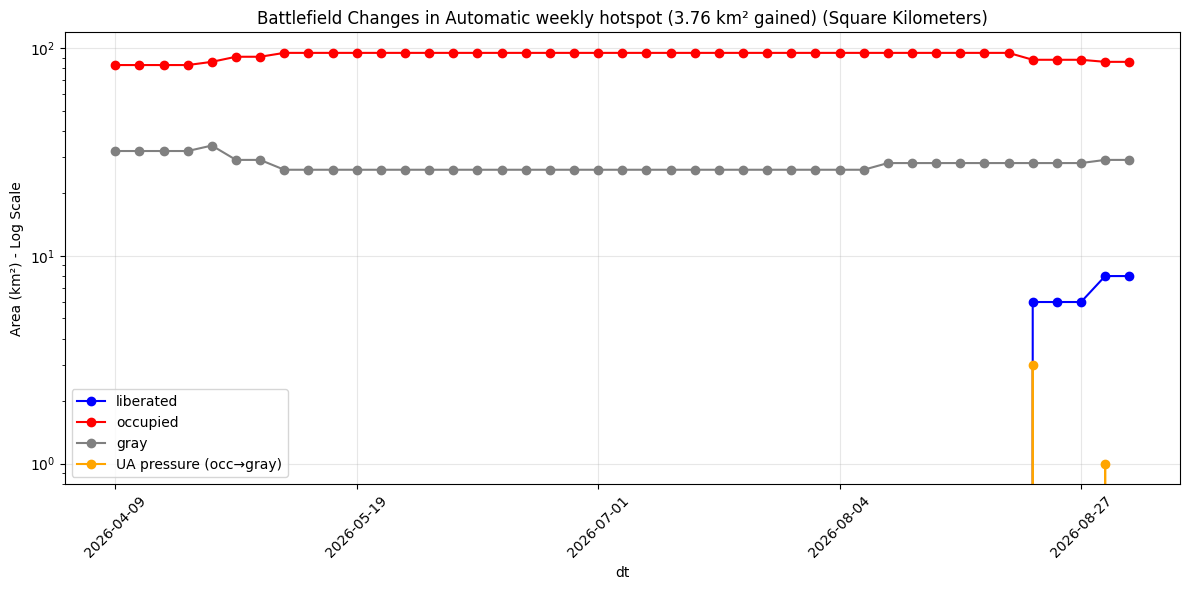

In [12]:
# ## Cell 6: Plot Time Series for Selected Area

from shapely.ops import unary_union as _uu

# Compute the occupied-to-gray pressure indicator.
# For each consecutive snapshot pair, this is the area that was classified
# as occupied in the earlier snapshot and as gray/unknown in the later one.
# It is the earliest measurable signal that Ukraine may be contesting
# ground that was firmly in Russian hands.
_km = 1_000_000
_dates = sorted(polygons_area.index.unique())
_pressure = {}

for _i in range(1, len(_dates)):
    _prev, _curr = _dates[_i - 1], _dates[_i]
    _prev_df = polygons_area[polygons_area.index == _prev]
    _curr_df = polygons_area[polygons_area.index == _curr]

    def _union_name(df, keyword):
        geoms = [
            g.buffer(0)
            for g in df[df['name'].str.contains(keyword, case=False, na=False)].geometry
            if g is not None and not g.is_empty
        ]
        return _uu(geoms) if geoms else None

    _occ_prev  = _union_name(_prev_df, 'occupied')
    _gray_curr = _union_name(_curr_df, 'unknown')

    if _occ_prev and _gray_curr and not _occ_prev.is_empty and not _gray_curr.is_empty:
        _pressure[_curr] = int(_occ_prev.intersection(_gray_curr).area / _km)
    else:
        _pressure[_curr] = 0

pressure_s = pd.Series(_pressure)

# Build the plot dataframe and add the pressure indicator.
df_plot = final_df[['liberated', 'occupied', 'gray']].copy()
df_plot['UA pressure (occ→gray)'] = pressure_s
df_plot = df_plot.loc[~(df_plot[['liberated', 'occupied', 'gray']] == 0).all(axis=1)]
df_plot = df_plot.dropna(how='all').fillna(0)

if len(df_plot) > 0:
    df_plot.index = df_plot.index.strftime('%Y-%m-%d')

    ax = df_plot.plot(
        marker='o',
        figsize=(12, 6),
        logy=True,
        rot=45,
        color={
            'liberated':             'blue',
            'occupied':              'red',
            'gray':                  'gray',
            'UA pressure (occ→gray)': 'orange',
        },
    )
    ax.set_title(f"Battlefield Changes in {area_name} (Square Kilometers)")
    ax.set_ylabel("Area (km\u00b2) - Log Scale")
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [13]:
# ## Cell 7: Load Current Full Ukraine Map from DeepState API

import requests

url = 'https://deepstatemap.live/api/history/last'
response = requests.get(url)

if response.status_code == 200:
    deep_state_data_raw = response.json()
    
    geo_list = []
    for f in deep_state_data_raw['map']['features']:
        geom = f['geometry']
        name = f['properties']['name']
        clean_geometry = wkt.loads(wkt.dumps(shape(geom), output_dimension=2))
        new_feature = {
            "name": name,
            "geometry": clean_geometry
        }
        geo_list.append(new_feature)
    
    for item in geo_list:
        item['name'] = extract_first_part(item['name'], part=1)
    
    gdf_ukraine = gpd.GeoDataFrame(geo_list)
    gdf_ukraine = gdf_ukraine.set_crs(4326)
    
    polygons_ukraine = gdf_ukraine[
        gdf_ukraine.geometry.apply(lambda x: isinstance(x, Polygon))
    ].copy()
    
    print(f"Loaded {len(polygons_ukraine)} polygons from DeepState API")
    
    # Calculate totals
    polygons_ukraine_proj = polygons_ukraine.to_crs(epsg=32636)
    targets = ['CADR and CALR', 'Occupied', 'Occupied Crimea']
    occupied_areas = polygons_ukraine_proj[polygons_ukraine_proj['name'].isin(targets)].copy()
    liberated_areas = polygons_ukraine_proj[
        polygons_ukraine_proj["name"].str.contains("liberated", case=False, na=False)
    ].copy()
    gray_areas = polygons_ukraine_proj[
        polygons_ukraine_proj["name"].str.contains("unknown", case=False, na=False)
    ].copy()
    
    km = 1_000_000
    print(f"\nFull Ukraine Statistics:")
    print(f"  Liberated areas: {int(liberated_areas.area.sum() / km)} km²")
    print(f"  Occupied areas: {int(occupied_areas.area.sum() / km)} km²")
    print(f"  Gray areas: {int(gray_areas.area.sum() / km)} km²")
else:
    print(f"Error fetching  {response.status_code}")



Loaded 124 polygons from DeepState API

Full Ukraine Statistics:
  Liberated areas: 41272 km²
  Occupied areas: 117174 km²
  Gray areas: 1711 km²


In [14]:
# ## Cell 8: Create Interactive Map with ipyleaflet

 
from ipywidgets import Layout, HTML

from ipyleaflet import (
    Map, basemaps, GeoJSON, LayersControl, Rectangle, Marker, WidgetControl
)
import json

# Get latest snapshot from area analysis
polygons_latest = polygons_area[polygons_area.index == polygons_area.index.max()].copy()

# Combine full Ukraine polygons with area-specific polygons
# Convert both to lat/lon (EPSG:4326)
polygons_ukraine_ll = polygons_ukraine.copy()  # Already in 4326
polygons_latest_ll = polygons_latest.to_crs(epsg=4326)

# Create combined GeoDataFrame
all_polygons = pd.concat([polygons_ukraine_ll, polygons_latest_ll], ignore_index=True)

# Keep only necessary columns
cols = ["name", "geometry"]
gdf_view = all_polygons[cols]

# Convert to GeoJSON
data = json.loads(gdf_view.to_json())

# Define styling function
def status_style(feature):
    name = (feature.get("properties", {}) or {}).get("name", "") or ""
    name_lower = name.lower()
    
    if "liberated" in name_lower:
        fill = "blue"
    elif "occupied" in name_lower:
        fill = "red"
    elif "unknown" in name_lower:
        fill = "gray"
    else:
        fill = "black"
    
    return {
        "color": "black",
        "weight": 2,
        "fillColor": fill,
        "fillOpacity": 0.4,
    }

# Center on the automatically selected hotspot. gdf_ukraine also contains
# several non-Ukraine territory layers, so its overall centroid is not a
# reliable map center.
top_left = area["top_left"]
bottom_right = area["bottom_right"]
min_lat_rect, max_lat_rect = sorted([top_left[0], bottom_right[0]])
min_lon_rect, max_lon_rect = sorted([top_left[1], bottom_right[1]])
hotspot_center = (
    (min_lat_rect + max_lat_rect) / 2,
    (min_lon_rect + max_lon_rect) / 2,
)
m = Map(
    center=hotspot_center,
    zoom=9,
    #basemap=basemaps.OpenStreetMap.Mapnik,
    basemap=basemaps.Esri.WorldStreetMap,
    layout=Layout(width="100%", height="650px"),
    scroll_wheel_zoom=True,
)

# Add all polygons
m.add_layer(GeoJSON(
    data=data,
    style={"opacity": 1, "fillOpacity": 0.4, "weight": 2},
    style_callback=status_style,
))

# Add rectangle showing analyzed area
rect = Rectangle(
    bounds=[(min_lat_rect, min_lon_rect), (max_lat_rect, max_lon_rect)],
    color="yellow",
    weight=3,
    fill=False,
)

m.add_layer(rect)

# Add a compact results label immediately above the analyzed-area boundary.
# Keep the two directions separate: the Ukrainian figure is the selected
# occupied-to-liberated transition (or the documented fallback), while the
# Russian figure is newly mapped occupied geometry, not an independently
# verified statement that Russia captured Ukrainian-controlled land.
period_label = (
    f"{hotspot['baseline_date'].strftime('%d %b %Y')}–"
    f"{hotspot['latest_date'].strftime('%d %b %Y')}"
)
if hotspot["method"] == "occupied to liberated":
    ukraine_label = (
        f"UA confirmed reclaimed: {hotspot['gain_km2_in_window']:.2f} km²"
    )
else:
    ukraine_label = (
        f"UA newly mapped liberated: {hotspot['gain_km2_in_window']:.2f} km²"
    )
pressure_label = (
    "UA pressure (occ→gray): "
    f"{hotspot['occupied_to_gray_km2_in_window']:.2f} km²"
)
russia_label = (
    "RU newly mapped occupied: "
    f"{hotspot['newly_occupied_km2_in_window']:.2f} km²"
)
label_html = f"""
<div style="
    width: 340px; padding: 8px 10px; background: rgba(255,255,255,0.94);
    border: 3px solid #ffd900; border-radius: 5px; color: #111;
    font: 13px/1.35 Arial, sans-serif; box-shadow: 0 2px 6px rgba(0,0,0,.35);
    text-align: left; white-space: nowrap;
">
  <strong><a href="https://deepstatemap.live/en#6/49.4383200/32.0526800" target="_blank" style="color:#111;text-decoration:underline">DeepStateMap.Live data</a> · {period_label}</strong><br>
  <span style="color:#1746c7;font-weight:700">{ukraine_label}</span><br>
  <span style="color:#e87c00;font-weight:700">{pressure_label}</span><br>
  <span style="color:#b51f1f;font-weight:700">{russia_label}</span><br>
  <span style="font-size:11px;color:#555">Walker Rowe analysis</span>
</div>
"""
 

label_widget = HTML(value=label_html)

label_control = WidgetControl(
    widget=label_widget,
    position="topright",
)

m.add_control(label_control)

m.add_control(LayersControl())

# Display the map
m

Map(center=[49.80969067807144, 37.57809324575495], controls=(ZoomControl(options=['position', 'zoom_in_text', …